In [1]:
import pandas as pd
import numpy as np
import glob 
import duckdb
import os
os.chdir("..")
import plotting_helpers
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm
from trebl_tools import plotting

# Calculating activity per BC combo

In [2]:
step1_map = pd.read_csv("../../output/GCN4_pipeline/step1.csv")
step1_map = step1_map[["AD", "AD_BC", "RPTR_BC"]].drop_duplicates()
step1_map

,AD,AD_BC,RPTR_BC
0,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC
1,GATGAATCTCCAACTTCTATGCCAGAAGATGTTGTTGTTGCTGATC...,GAGCCGTGGAA,GGTGACAGCAATGC
2,TCTTCTCCAGTTGTTAAACCAGTTTCTTCTCCAGCTAGATCTCCAA...,ACTCCGAGAAA,TTATAAAAGATTGC
3,CAACCATCTCATCAAGACTTTGTCTTGTTTGAAAGATCTCCATCTG...,ACGCATGCTCA,ACGCTGACCCGTAC
4,ACTCCAAATATGGTTATGCAAGATATGGATTTGTTTGATGACTTTA...,CTAATTTTATC,GATCGACAACGCCC
...,...,...,...
172971,GCTCCAACTCATCAAGCTATGATTGCTGATATTATTGTTAAGAATG...,TACGAAATCTG,GCTATGAACCGAAG
172972,GACTTTAATACTGCTGTTCCAACTATTTCTCCACAAGAATTGTTGA...,GATCAGATTGA,CCTTGGTAACTATC
172973,ACTTCTTTGAGATCTTCTCCATCTTCTAGAGTTCATTTGCAAAGAT...,TGGGAATGCTA,AATTGAGACTAATG
172974,AATTCTACTGCATTTACTAATTTGACTTCTCCATCTACTTATAATG...,ATTTCTTAAGA,TCTAAGCCCGAATG


In [3]:
AD_results = pd.read_csv("../../output/GCN4_pipeline/AD_trebl_experiment_pool_C_PolyT_results.csv")
AD_results["rep"] = AD_results["sample"].astype(str).str.extract(r'AD_(\d+)').astype(int)
AD_results["time"] = AD_results["sample"].astype(str).str.extract(r'AD_\d+_(\d+)').astype(int)
AD_results

,AD,AD_BC,count,sample,rep,time
0,AAACATTCTTCTGTTGCTGGTGTTAATTCTAGAAGAAGAGATAAAA...,TACCCTGTCAC,36381,AD_2_0_S1_L001_AD_AD_BC_thresholded,2,0
1,AGACCAGCTAGACCACCAGTTCCATTGTTCTCTCAATCTACTGGTT...,TCCTAAGCTCG,36028,AD_2_0_S1_L001_AD_AD_BC_thresholded,2,0
2,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...,TTATTCGAATT,33561,AD_2_0_S1_L001_AD_AD_BC_thresholded,2,0
3,GCTACTATTCCACCATTTGATGTTAAACATTTACTACTGATTCTAA...,TGTGACCCCGC,28436,AD_2_0_S1_L001_AD_AD_BC_thresholded,2,0
4,TTGGGTGTTATTACTTATAATAGGAAACAAAGAGCTACTCCATTGA...,CTACGGAACTC,26593,AD_2_0_S1_L001_AD_AD_BC_thresholded,2,0
...,...,...,...,...,...,...
615276,CCACAAACTCCAAATTGGCTATGCAAGGTAATTATTCTTCTTCTGA...,TAGAGAACGCG,21,AD_4_5_S16_L001_AD_AD_BC_thresholded,4,5
615277,TCTCCCATTTGTCTAATAATCAAAATTCTCCAGGTGCTACTGTTTC...,TATTGGCCCGT,21,AD_4_5_S16_L001_AD_AD_BC_thresholded,4,5
615278,GAATTTGAAGTTTCTGAACATTTGGAAATTCTACTGGTAGAAGAAG...,ATGTTAAAGTT,21,AD_4_5_S16_L001_AD_AD_BC_thresholded,4,5
615279,TTTGAACCAAATGAATTGGAAATTCCACCAGTTGTTGCTGCTGCTA...,AAAAAAAGACG,21,AD_4_5_S16_L001_AD_AD_BC_thresholded,4,5


In [4]:
RT_results = pd.read_csv("../../output/GCN4_pipeline/RT_trebl_experiment_pool_C_PolyT_results.csv")
RT_results["rep"] = RT_results["sample"].astype(str).str.extract(r'RPTR_(\d+)').astype(int)
RT_results["time"] = RT_results["sample"].astype(str).str.extract(r'RPTR_\d+_(\d+)').astype(int)
RT_results

,RPTR_BC,count,sample,rep,time
0,TTATTTAGAAGTTT,69655,RPTR_2_0_S22_L001_RPTR_BC_thresholded,2,0
1,GGAGGGGTCAGAAG,31020,RPTR_2_0_S22_L001_RPTR_BC_thresholded,2,0
2,GTCACCAACGTTTA,24266,RPTR_2_0_S22_L001_RPTR_BC_thresholded,2,0
3,CCCCAGACTCGTTG,21376,RPTR_2_0_S22_L001_RPTR_BC_thresholded,2,0
4,TATGTTGTAGCTTA,19114,RPTR_2_0_S22_L001_RPTR_BC_thresholded,2,0
...,...,...,...,...,...
496449,ATAATACATCATTG,21,RPTR_4_5_S37_L001_RPTR_BC_thresholded,4,5
496450,CTGGGACGAACAAA,21,RPTR_4_5_S37_L001_RPTR_BC_thresholded,4,5
496451,CCACCACGCTATCC,21,RPTR_4_5_S37_L001_RPTR_BC_thresholded,4,5
496452,ATGAAACTTAAATC,21,RPTR_4_5_S37_L001_RPTR_BC_thresholded,4,5


In [5]:
step1_map_AD = pd.merge(step1_map, AD_results).drop(columns = 'sample')
step1_map_AD

,AD,AD_BC,RPTR_BC,count,rep,time
0,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,201,2,0
1,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,191,2,10
2,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,198,2,15
3,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,139,2,180
4,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,160,2,240
...,...,...,...,...,...,...
376399,GAAGCTGCTAGGAAATCTAGAGCTAGGAAATTGGAAAGACAAGAAG...,GATAGTAATGT,GGTAAATACACAAA,1395,4,15
376400,GAAGCTGCTAGGAAATCTAGAGCTAGGAAATTGGAAAGACAAGAAG...,GATAGTAATGT,GGTAAATACACAAA,1651,4,180
376401,GAAGCTGCTAGGAAATCTAGAGCTAGGAAATTGGAAAGACAAGAAG...,GATAGTAATGT,GGTAAATACACAAA,1526,4,240
376402,GAAGCTGCTAGGAAATCTAGAGCTAGGAAATTGGAAAGACAAGAAG...,GATAGTAATGT,GGTAAATACACAAA,1694,4,30


In [6]:
step1_map_RT = pd.merge(step1_map, RT_results).drop(columns = 'sample')
step1_map_RT

,AD,AD_BC,RPTR_BC,count,rep,time
0,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,157,2,0
1,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,127,2,10
2,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,127,2,15
3,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,108,2,180
4,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,77,2,240
...,...,...,...,...,...,...
310854,GAAGCTGCTAGGAAATCTAGAGCTAGGAAATTGGAAAGACAAGAAG...,GATAGTAATGT,GGTAAATACACAAA,709,4,15
310855,GAAGCTGCTAGGAAATCTAGAGCTAGGAAATTGGAAAGACAAGAAG...,GATAGTAATGT,GGTAAATACACAAA,478,4,180
310856,GAAGCTGCTAGGAAATCTAGAGCTAGGAAATTGGAAAGACAAGAAG...,GATAGTAATGT,GGTAAATACACAAA,649,4,240
310857,GAAGCTGCTAGGAAATCTAGAGCTAGGAAATTGGAAAGACAAGAAG...,GATAGTAATGT,GGTAAATACACAAA,604,4,30


In [7]:
AD_RT_merged = pd.merge(step1_map_AD, step1_map_RT, how = 'outer', on = ["AD", "AD_BC", "RPTR_BC", "rep", "time"], suffixes = ("_AD", "_RT"))
AD_RT_merged

,AD,AD_BC,RPTR_BC,count_AD,rep,time,count_RT
0,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,122.0,2,0,101.0
1,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,203.0,2,5,72.0
2,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,180.0,2,10,56.0
3,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,174.0,2,15,53.0
4,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,129.0,2,30,33.0
...,...,...,...,...,...,...,...
387193,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,685.0,4,10,627.0
387194,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,671.0,4,15,817.0
387195,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,591.0,4,30,695.0
387196,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,626.0,4,180,389.0


In [8]:
sum(AD_RT_merged["count_AD"].isna())

10794

In [9]:
sum(AD_RT_merged["count_RT"].isna())

76339

In [10]:
# For now, ignore the nulls
AD_RT_merged = AD_RT_merged.dropna()
AD_RT_merged

,AD,AD_BC,RPTR_BC,count_AD,rep,time,count_RT
0,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,122.0,2,0,101.0
1,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,203.0,2,5,72.0
2,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,180.0,2,10,56.0
3,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,174.0,2,15,53.0
4,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,129.0,2,30,33.0
...,...,...,...,...,...,...,...
387193,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,685.0,4,10,627.0
387194,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,671.0,4,15,817.0
387195,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,591.0,4,30,695.0
387196,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,626.0,4,180,389.0


In [11]:
AD_RT_merged["activity"] = AD_RT_merged["count_RT"] / AD_RT_merged["count_AD"]
AD_RT_merged

,AD,AD_BC,RPTR_BC,count_AD,rep,time,count_RT,activity
0,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,122.0,2,0,101.0,0.827869
1,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,203.0,2,5,72.0,0.354680
2,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,180.0,2,10,56.0,0.311111
3,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,174.0,2,15,53.0,0.304598
4,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,129.0,2,30,33.0,0.255814
...,...,...,...,...,...,...,...,...
387193,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,685.0,4,10,627.0,0.915328
387194,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,671.0,4,15,817.0,1.217586
387195,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,591.0,4,30,695.0,1.175973
387196,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,626.0,4,180,389.0,0.621406


In [12]:
AD_RT_merged.to_csv("../../output/GCN4_pipeline/trebl_experiment_pool_C_PolyT_results_per_barcode.csv")

# Saving barcode loss

In [2]:
db_path = "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/duckdb/GCN4_pipeline.db"
con = duckdb.connect(db_path)

In [3]:
AD_prefixes_df, RT_prefixes_df = plotting_helpers.get_prefix_df("pool_C_PolyT", con)
AD_prefixes_df, RT_prefixes_df = AD_prefixes_df.dropna(), RT_prefixes_df.dropna()

trebl_experiment_pool_C_PolyT_AD_2_0_S1_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_0_S1_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_10_S3_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_10_S3_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_15_S4_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_15_S4_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_180_S6_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_180_S6_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_240_S7_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_240_S7_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_30_S5_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_30_S5_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_5_S2_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_2_5_S2_L001_AD_AD_BC_loss_summary
trebl_experiment_pool_C_PolyT_AD_3_0_S8_L001_AD_

In [4]:
AD_prefixes_df

,id,rep,time
0,trebl_experiment_pool_C_PolyT_AD_2_0_S1_L001_A...,2,0
7,trebl_experiment_pool_C_PolyT_AD_3_0_S8_L001_A...,3,0
14,trebl_experiment_pool_C_PolyT_AD_4_0_S15_L001_...,4,0
1,trebl_experiment_pool_C_PolyT_AD_2_10_S3_L001_...,2,10
8,trebl_experiment_pool_C_PolyT_AD_3_10_S10_L001...,3,10
15,trebl_experiment_pool_C_PolyT_AD_4_10_S17_L001...,4,10
2,trebl_experiment_pool_C_PolyT_AD_2_15_S4_L001_...,2,15
9,trebl_experiment_pool_C_PolyT_AD_3_15_S11_L001...,3,15
16,trebl_experiment_pool_C_PolyT_AD_4_15_S18_L001...,4,15
3,trebl_experiment_pool_C_PolyT_AD_2_180_S6_L001...,2,180


In [5]:
AD_loss_table_dict = plotting_helpers.build_loss_table_dict(AD_prefixes_df["id"], con, step1_table = "../../output/GCN4_pipeline/step1.csv")
RT_loss_table_dict = plotting_helpers.build_loss_table_dict(RT_prefixes_df["id"], con, step1_table = "../../output/GCN4_pipeline/step1.csv")

registering temp step1


100%|██████████| 21/21 [00:04<00:00,  4.89it/s]


registering temp step1


100%|██████████| 21/21 [00:01<00:00, 18.01it/s]


In [6]:
AD_prefixes_df["rep"] = AD_prefixes_df["rep"].astype(int)
AD_prefixes_df["time"] = AD_prefixes_df["time"].astype(int)
AD_prefixes_df = AD_prefixes_df.sort_values(by = ["time", "rep"])
AD_prefixes_df

,id,rep,time
0,trebl_experiment_pool_C_PolyT_AD_2_0_S1_L001_A...,2,0
7,trebl_experiment_pool_C_PolyT_AD_3_0_S8_L001_A...,3,0
14,trebl_experiment_pool_C_PolyT_AD_4_0_S15_L001_...,4,0
6,trebl_experiment_pool_C_PolyT_AD_2_5_S2_L001_A...,2,5
13,trebl_experiment_pool_C_PolyT_AD_3_5_S9_L001_A...,3,5
20,trebl_experiment_pool_C_PolyT_AD_4_5_S16_L001_...,4,5
1,trebl_experiment_pool_C_PolyT_AD_2_10_S3_L001_...,2,10
8,trebl_experiment_pool_C_PolyT_AD_3_10_S10_L001...,3,10
15,trebl_experiment_pool_C_PolyT_AD_4_10_S17_L001...,4,10
2,trebl_experiment_pool_C_PolyT_AD_2_15_S4_L001_...,2,15


In [7]:
RT_prefixes_df["rep"] = RT_prefixes_df["rep"].astype(int)
RT_prefixes_df["time"] = RT_prefixes_df["time"].astype(int)
RT_prefixes_df = RT_prefixes_df.sort_values(by = ["rep", "time"])
RT_prefixes_df

,id,rep,time
0,trebl_experiment_pool_C_PolyT_RPTR_2_0_S22_L00...,2,0
6,trebl_experiment_pool_C_PolyT_RPTR_2_5_S23_L00...,2,5
1,trebl_experiment_pool_C_PolyT_RPTR_2_10_S24_L0...,2,10
2,trebl_experiment_pool_C_PolyT_RPTR_2_15_S25_L0...,2,15
5,trebl_experiment_pool_C_PolyT_RPTR_2_30_S26_L0...,2,30
3,trebl_experiment_pool_C_PolyT_RPTR_2_180_S27_L...,2,180
4,trebl_experiment_pool_C_PolyT_RPTR_2_240_S28_L...,2,240
7,trebl_experiment_pool_C_PolyT_RPTR_3_0_S29_L00...,3,0
13,trebl_experiment_pool_C_PolyT_RPTR_3_5_S30_L00...,3,5
8,trebl_experiment_pool_C_PolyT_RPTR_3_10_S31_L0...,3,10


100%|██████████| 21/21 [00:26<00:00,  1.26s/it]


Text(0.5, 1.02, 'Yeast Pool B, AD Trebl Experiment')

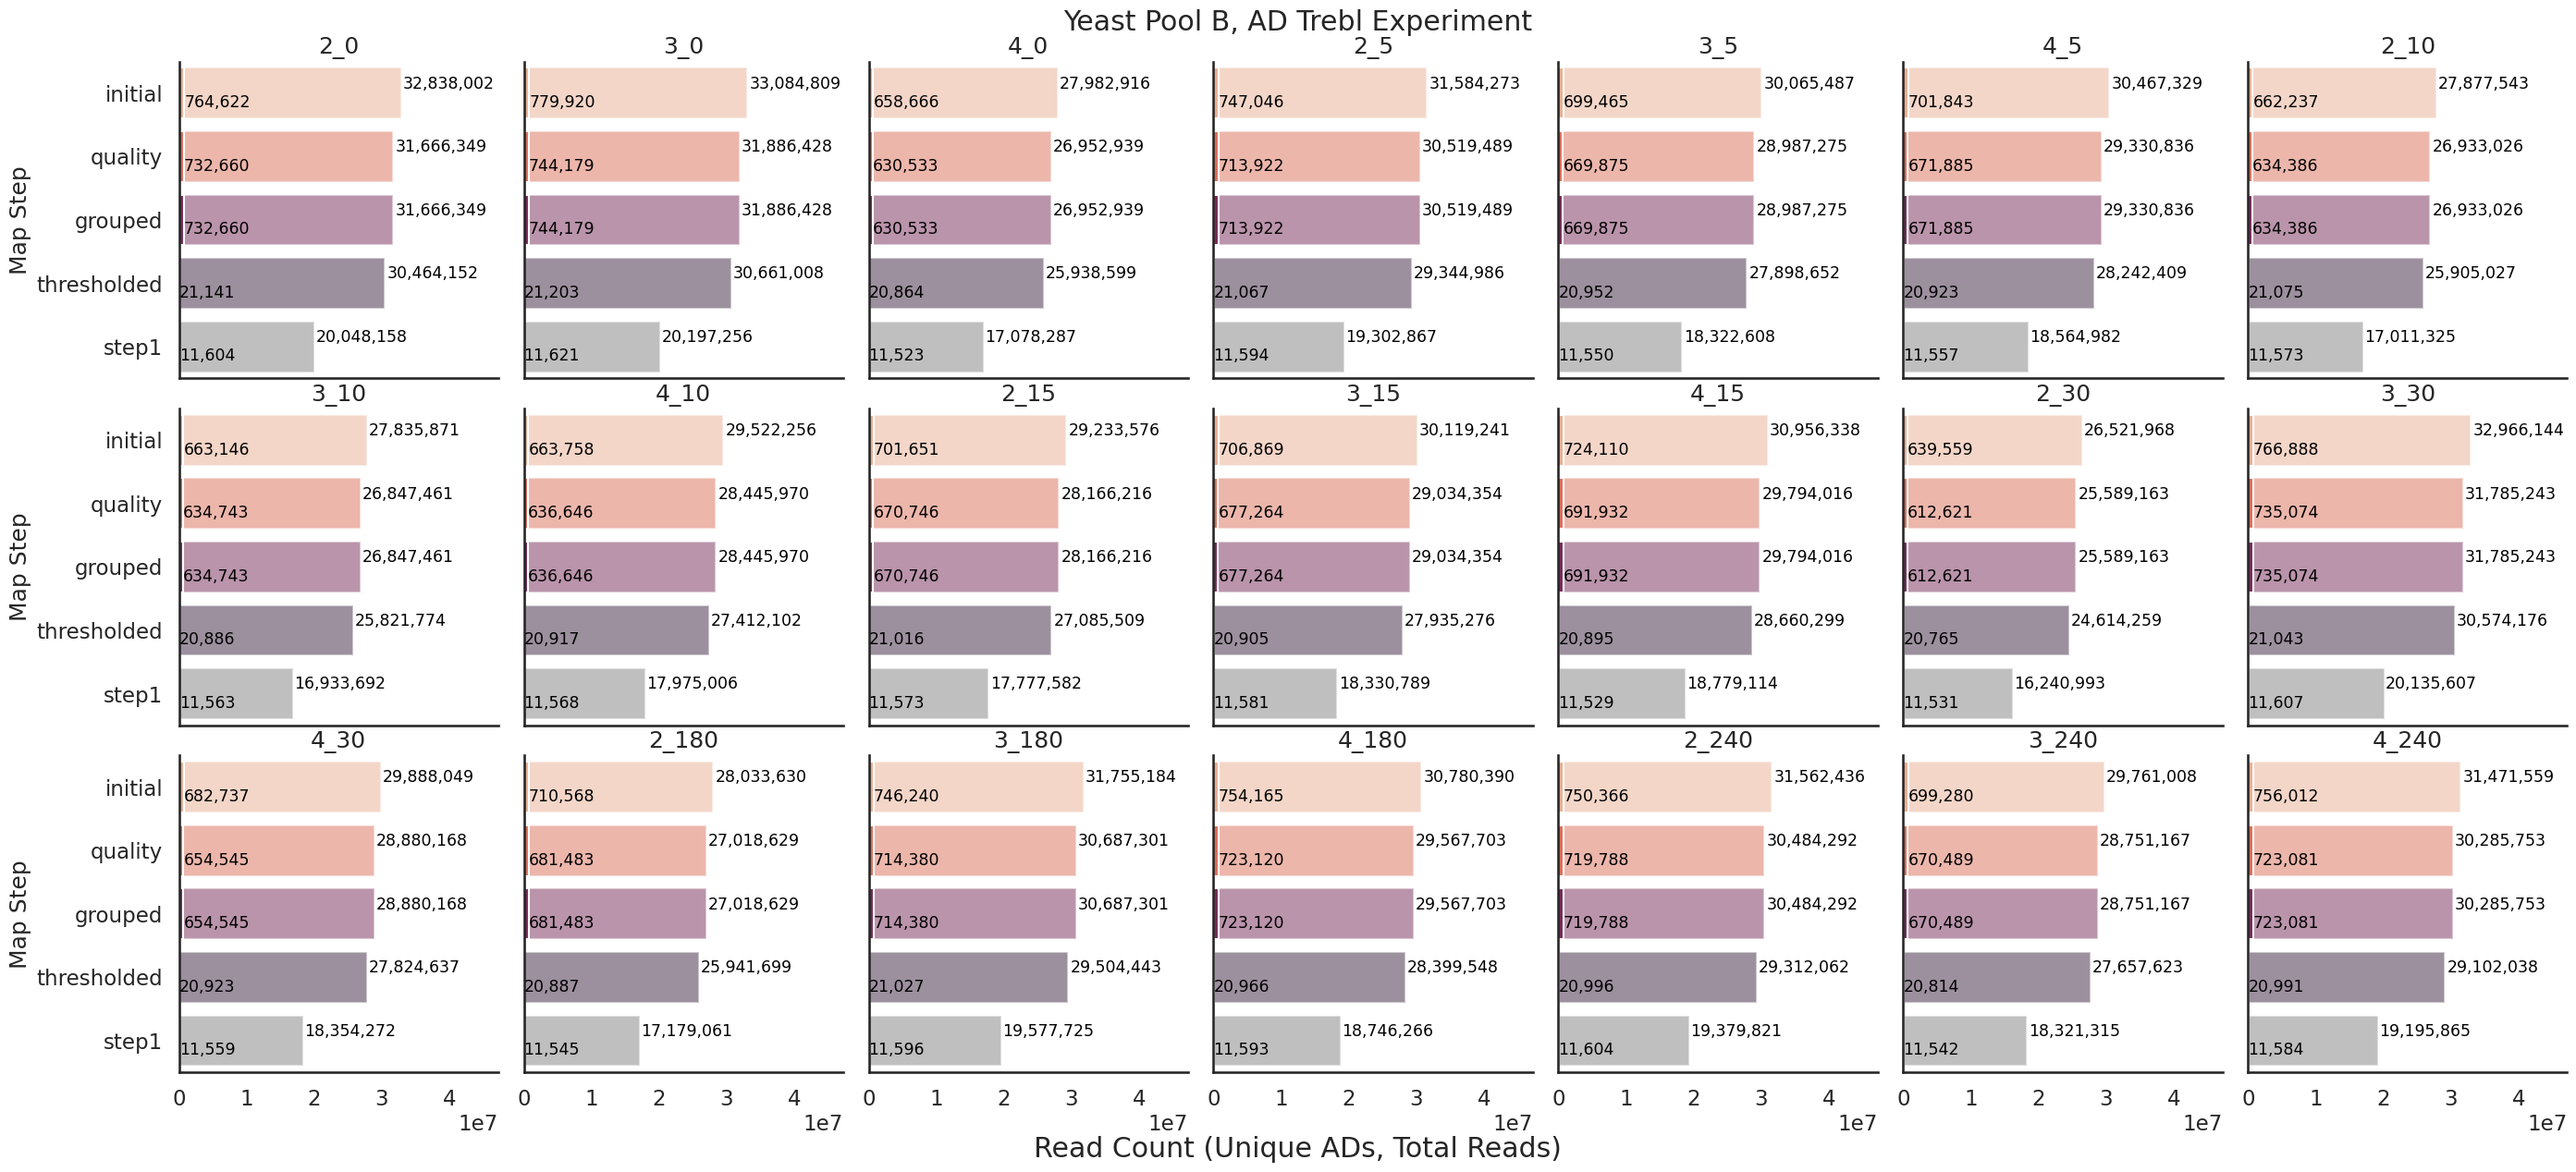

In [8]:
fig, axs = plt.subplots(3,7, sharey = True, sharex = True, figsize = (28,12))
axs = axs.flatten()

i = 0
for table in tqdm.tqdm(AD_prefixes_df["id"]):
    df = AD_loss_table_dict[table]
    df = df.drop(columns = "unique_count")
    df = df.rename(columns = {"unique_AD_count" : "unique_count"})
    
    plotting.plot_loss_helper(ax = axs[i], 
                                palette = 'rocket_r', 
                                text_offset =-0.15, 
                                show_background = True, 
                                default_map_order = ['initial', 'quality', 'designed', 'grouped', 'thresholded'], 
                                output_figures_path = "../../output/GCN4/figures/trebl_experiment_test",
                                table_prefix_with_descriptor = "test",
                                  df = df, 
                              hide_x = False)
    axs[i].set_title(str(AD_prefixes_df["rep"].iloc[i]) + "_" + str(AD_prefixes_df["time"].iloc[i]))
    i += 1
    

for ax in axs:
    ax.set_xlabel("")

    
plt.tight_layout(pad = 0.25)
fig.supxlabel("Read Count (Unique ADs, Total Reads)", y = -0.02)
plt.suptitle("Yeast Pool B, AD Trebl Experiment", y = 1.02)

100%|██████████| 21/21 [00:25<00:00,  1.21s/it]


Text(0.5, 1.02, 'Yeast Pool B, RT Trebl Experiment')

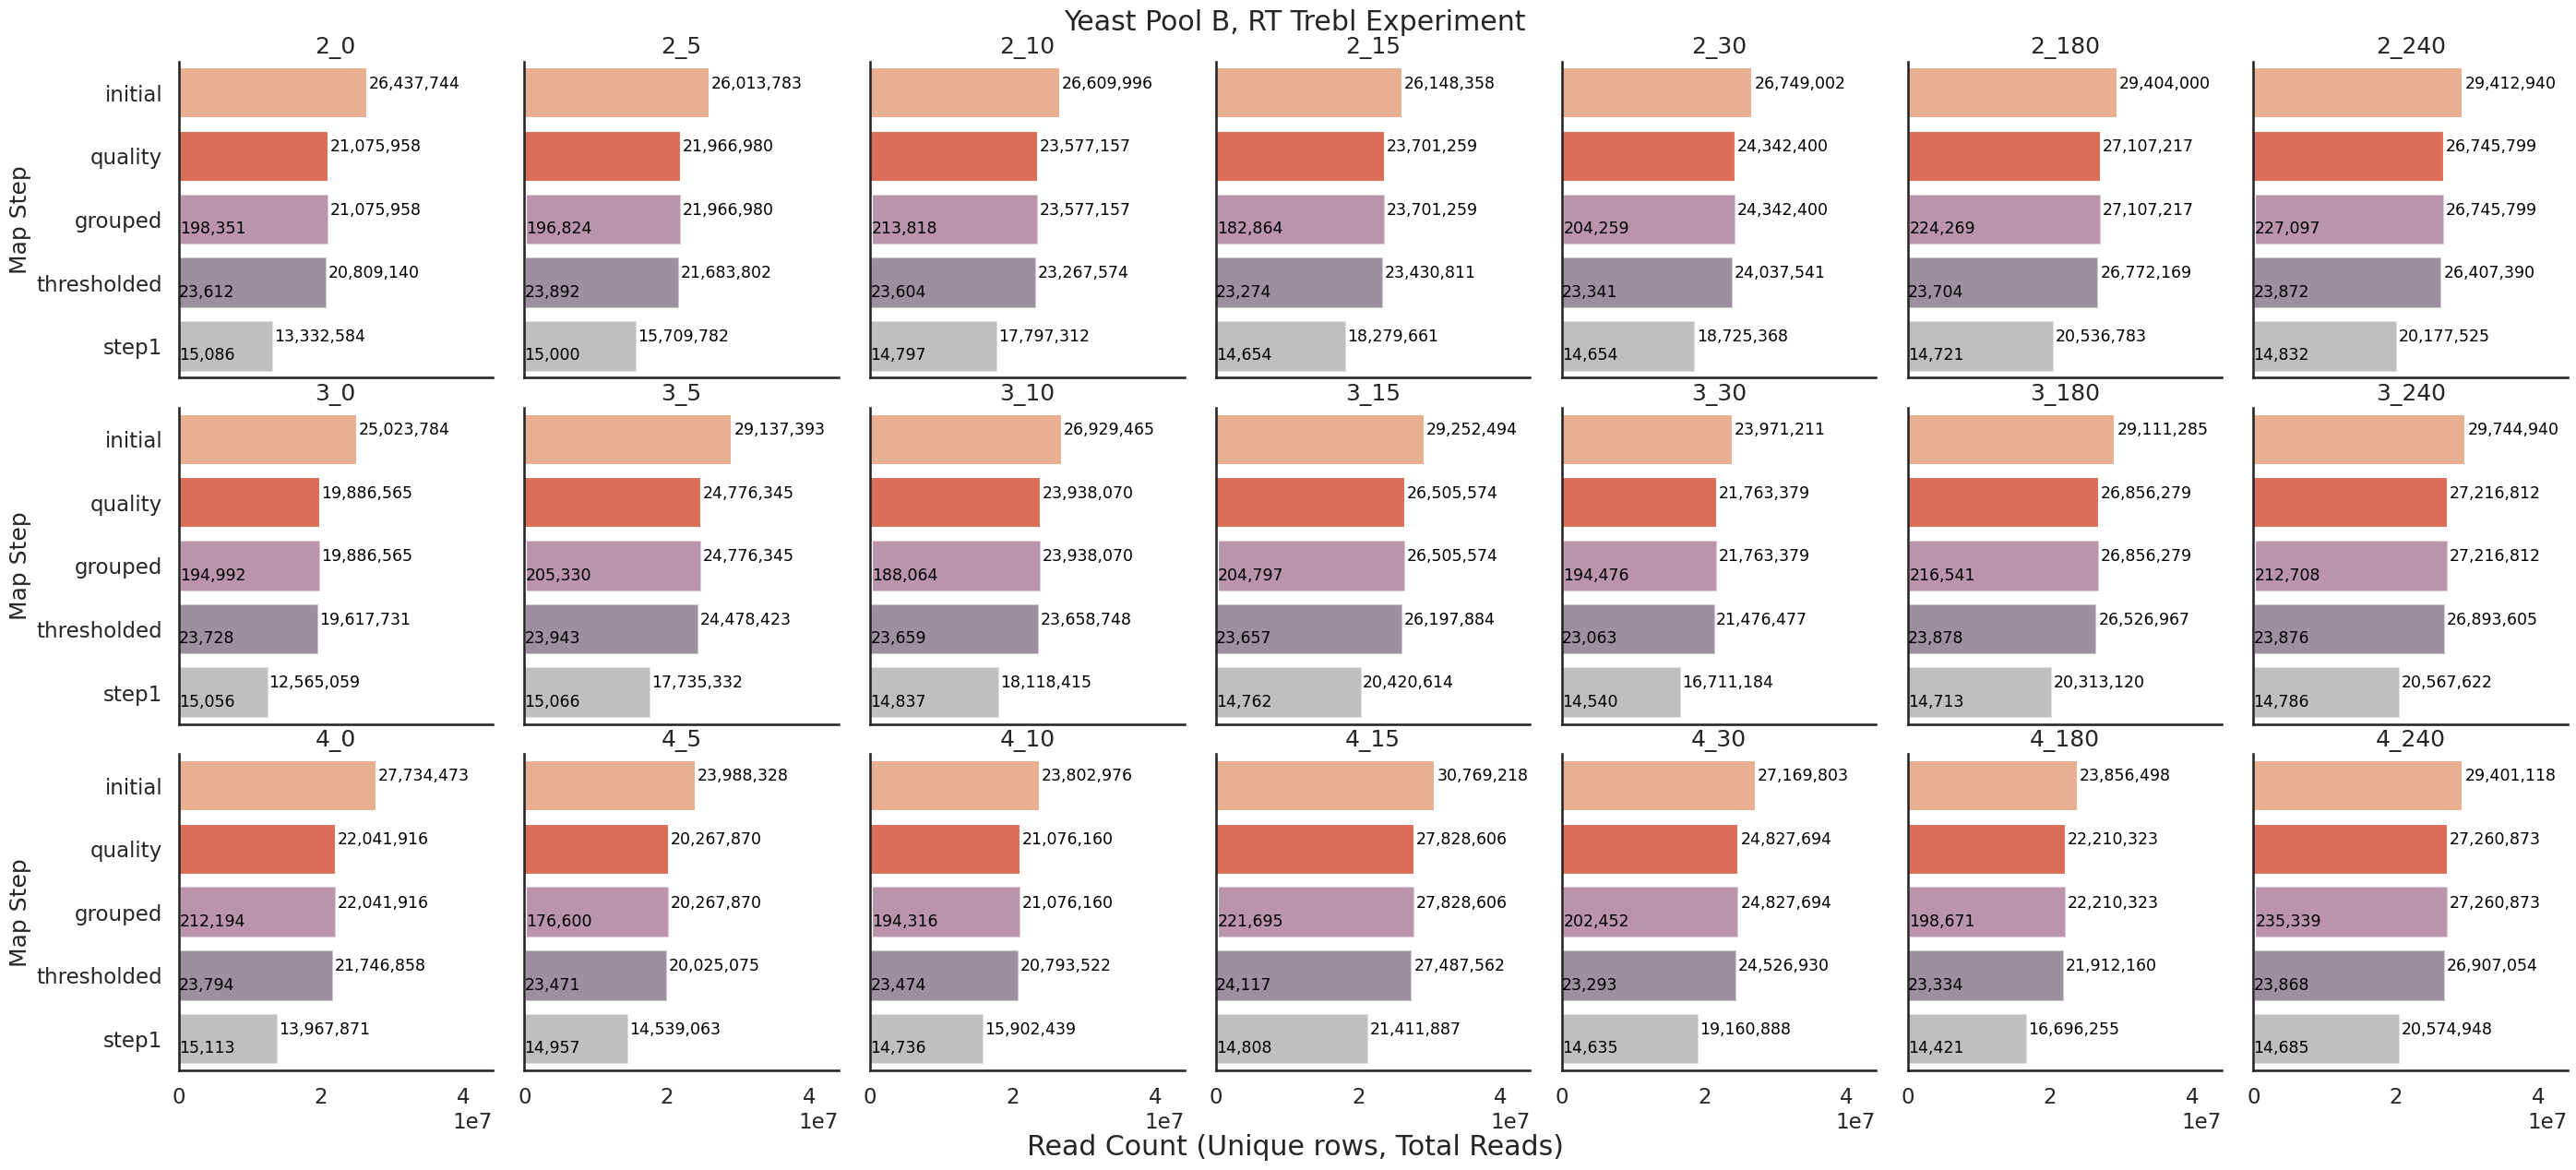

In [9]:
fig, axs = plt.subplots(3,7, sharey = True, sharex = True, figsize = (28,12))
axs = axs.flatten()

i = 0
for table in tqdm.tqdm(RT_prefixes_df["id"]):
    df = RT_loss_table_dict[table]

    plotting.plot_loss_helper(ax = axs[i], 
                                palette = 'rocket_r', 
                                text_offset =-0.15, 
                                show_background = True, 
                                default_map_order = ['initial', 'quality', 'designed', 'grouped', 'thresholded'], 
                                output_figures_path = "../../output/GCN4/figures/trebl_experiment_test",
                                table_prefix_with_descriptor = "test",
                                  df = df, 
                              hide_x = False)
    axs[i].set_title(str(RT_prefixes_df["rep"].iloc[i]) + "_" + str(RT_prefixes_df["time"].iloc[i]))
    i += 1
    

for ax in axs:
    ax.set_xlabel("")

    
plt.tight_layout(pad = 0.25)
fig.supxlabel("Read Count (Unique rows, Total Reads)", y = -0.02)
plt.suptitle("Yeast Pool B, RT Trebl Experiment", y = 1.02)

In [10]:
con.close()